Dataset Loaded Successfully

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

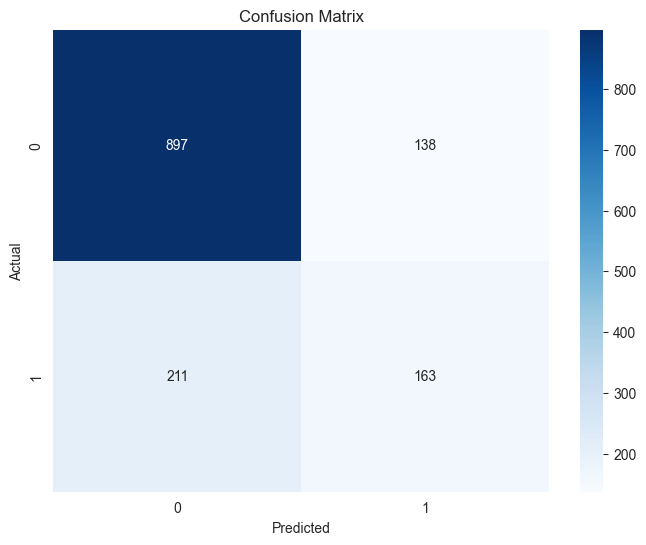


Files Saved Successfully

Generated Files:

models/churn_model.pkl
models/scaler.pkl



In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Dataset

df = pd.read_csv("/Users/adityasaurav/Downloads/Customer-Churn.csv")

print("Dataset Loaded Successfully\n")

print(df.head())

# Data Cleaning

# Remove customer ID
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Convert target variable
df["Churn"] = df["Churn"].map(
    {
        "No":0,
        "Yes":1
    }
)

print("\nData Cleaning Completed")

# Select Features

X = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
]

y = df["Churn"]

print("\nFeatures Selected")

# Check Class Distribution

print("\nClass Distribution")

print(
    y.value_counts()
)

# Split Dataset

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Test Split Completed")


# Scaling


scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

print("\nScaling Completed")


# Train Model


model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("\nModel Training Completed")


# Prediction


predictions = model.predict(
    X_test
)


# Accuracy


accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nAccuracy:",accuracy)


# Classification Report


print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


# Confusion Matrix


cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

# Save Models


os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    model,
    "models/churn_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("\nFiles Saved Successfully")

print(
"""
Generated Files:

models/churn_model.pkl
models/scaler.pkl
"""
)